# Plot

In [2]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import glob
import pyslha

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disabpd.option_context('display.max_columns', 300)le copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Collect information about scan

In [34]:
pts = []
for f in glob.glob('./2018-19_pMSSM_points/*slha'):
    slhaData = pyslha.readSLHAFile(f)
    
    xsec_c1c1 = 0.0
    xsec_c1n1 = 0.0
    try:
        xsec_c1c1 = [xsec for xsec in slhaData.xsections.get((2212,2212,-1000024,1000024)).xsecs if xsec.qcd_order > 0 and xsec.sqrts == 13000.][0].value
    except:
        pass
    try:
        xsec_c1n1 = [xsec for xsec in slhaData.xsections.get((2212,2212,-1000024,1000022)).xsecs if xsec.qcd_order > 0 and xsec.sqrts == 13000.][0].value
    except:
        pass
    try:
        xsec_c1n1 += [xsec for xsec in slhaData.xsections.get((2212,2212,1000022,1000024)).xsecs if xsec.qcd_order > 0 and xsec.sqrts == 13000.][0].value
    except:
        pass
    pointDict = {'mLLP' : slhaData.blocks['MASS'][1000024],
                 'tau_ns' : 6.58e-16/slhaData.decays[1000024].totalwidth,
                 'xsec_c1c1_fb' : xsec_c1c1*1e3, 'xsec_c1n1_fb' : xsec_c1n1*1e3}
    pts.append(pointDict)


In [35]:
df = pd.DataFrame.from_dict(pts)

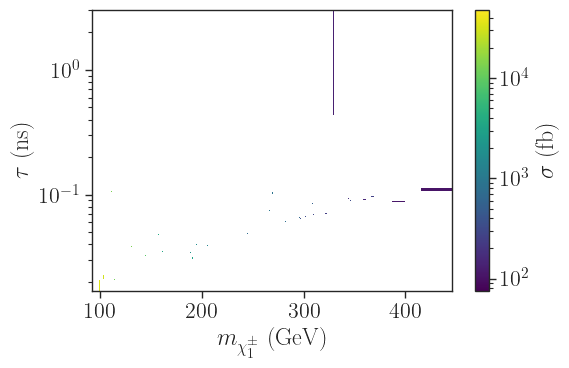

In [42]:
plt.figure(figsize=(6,4))

labels = [r'$p p \to \chi_1^\pm \chi_1^\mp$',r'$p p \to \chi_1^\pm \chi_1^0$']

x = df['mLLP']
y = df['tau_ns']
z = df['xsec_c1c1_fb']+df['xsec_c1n1_fb']

# p = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-4,min(z)),vmax=max(z)))
counts, xedges, yedges, im = plt.hist2d(x,y,bins=[sorted(x),sorted(y)],weights=z, cmap='viridis',
                                        norm=LogNorm(vmin=min(z),vmax=max(z)))

plt.yscale('log')
plt.ylabel(r'$\tau$ (ns)')
plt.xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
plt.colorbar(label=r'$\sigma$ (fb)')


# cbar_ax = fig.add_axes([0.99, 0.25, 0.01, 0.6])
# fig.colorbar(p,label=r'$\epsilon$',cax=cbar_ax)
plt.tight_layout()
plt.show()

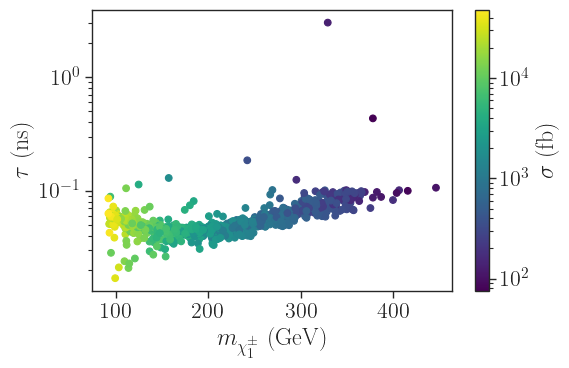

In [43]:
plt.figure(figsize=(6,4))

labels = [r'$p p \to \chi_1^\pm \chi_1^\mp$',r'$p p \to \chi_1^\pm \chi_1^0$']

x = df['mLLP']
y = df['tau_ns']
z = df['xsec_c1c1_fb']+df['xsec_c1n1_fb']

# p = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-4,min(z)),vmax=max(z)))
plt.scatter(x,y,c=z, cmap='viridis',
                 norm=LogNorm(vmin=min(z),vmax=max(z)))

plt.yscale('log')
plt.ylabel(r'$\tau$ (ns)')
plt.xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
plt.colorbar(label=r'$\sigma$ (fb)')


# cbar_ax = fig.add_axes([0.99, 0.25, 0.01, 0.6])
# fig.colorbar(p,label=r'$\epsilon$',cax=cbar_ax)
plt.tight_layout()
plt.show()

### Check point

In [48]:
mLLP = max(df['mLLP'])
tau = df['tau_ns'].loc[df['mLLP'].idxmax()]
xsec_c1c1 = df['xsec_c1c1_fb'].loc[df['mLLP'].idxmax()]
xsec_c1n1 = df['xsec_c1n1_fb'].loc[df['mLLP'].idxmax()]
print(mLLP,tau,xsec_c1c1,xsec_c1n1)

xsecs_c1c1 = np.genfromtxt('xsec_13TeV_pp2chgchg_fb.csv',delimiter=',',names=True)
xsecs_c1n1 = np.genfromtxt('xsec_13TeV_pp2chgn1_fb.csv',delimiter=',',names=True)
im = np.argmin(np.abs(xsecs_c1c1['mass']-mLLP))
xsec_c1c1,xsec_c1c1_error = xsecs_c1c1['xsec'][im],xsecs_c1c1['unc'][im]
im = np.argmin(np.abs(xsecs_c1n1['mass']-mLLP))
xsec_c1n1,xsec_c1n1_error = xsecs_c1n1['xsec'][im],xsecs_c1n1['unc'][im]

xsec_tot = xsec_c1c1+xsec_c1n1
eff_res = 7.6e-4
sigma_UL_atlas_fb = 0.037 # Limit from https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/SUSY-2018-19/tab_08.png
print(f"Effective efficiency = {eff_res:1.3e}")
print(f"Total xsec (fb) = {xsec_tot:1.3e}")
print(f"Visible xsec (fb) = {xsec_tot*eff_res:1.3e}")
print(f"r = {xsec_tot*eff_res/sigma_UL_atlas_fb:1.2f}")


446.116269 0.10625873921609447 34.395001 71.445235
Effective efficiency = 7.600e-04
Total xsec (fb) = 1.088e+02
Visible xsec (fb) = 8.265e-02
r = 2.23
